**Name:** Benyi Chen

**EID:** 60960961

# CS5495 - Tutorial 2
## Interpretable Linear Models - Housing Data

In this tutorial, you interpret models trained on housing data.

First we need to initialize Python.  Run the below cell.

In [1]:
# setup
%matplotlib inline
import matplotlib_inline   # setup output image format
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100  # display larger images
import matplotlib
from numpy import *
from sklearn import *
from scipy import stats
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
pd.set_option('display.precision', 5)
import statsmodels.api as sm

In [2]:
# environment
import sys
print(sys.executable)

# toolbox version
import statsmodels
print(statsmodels.__version__)

/Users/Link/miniforge3/envs/BY/bin/python
0.14.6


## Helper functions
- These are helper functions from the lecture

In [4]:
def make_scaler_df(featnames, scaler):
    df = pd.DataFrame({
     'mean': scaler.mean_,
     'std' : sqrt(scaler.var_),
      }, index=featnames )
    return df
    
def color_p(value):
  if value < 0.05:
    color = 'green'
  else:
    color = 'red'
  return 'color: %s' % color

def get_summary(model):
    tmp = pd.DataFrame({
      'Weight':  model.params,
      'CI-lower': model.conf_int()[0],
      'CI-upper': model.conf_int()[1],
      'SE':      model.bse,
      '|t|':     model.tvalues.abs(),
      'p-value': model.pvalues,
    })
    tmp=tmp.style.map(color_p, subset=['p-value']).format('{:.5f}')
    return tmp

def plot_weights(model, showconst=True):
    # Create a DataFrame for plotting weights and CI
    plot_df = pd.DataFrame({
        'coef': model.params,
        'lower': model.conf_int()[0],
        'upper': model.conf_int()[1]
    })

    if (not showconst):
        plot_df = plot_df.drop(index=['const'])
    
    # Plotting the weight plot with 95% confidence intervals
    fig1 = plt.figure(figsize=(8, 4))
    plt.errorbar(plot_df['coef'],plot_df.index,
                 xerr=[plot_df['coef'] - plot_df['lower'], plot_df['upper'] - plot_df['coef']],
                 fmt='o', color='blue', ecolor='gray', capsize=5)
    plt.axvline(0, color='red', linestyle='--')
    plt.title('Weights with 95% Confidence Intervals')
    plt.grid(True); plt.tight_layout()
    plt.close()
    return fig1

def calculate_effects(model, X):
    # Extract coefficients
    weights = model.params
    
    # Calculate effects: effect = feature value × weight
    effects = X.mul(weights, axis=1)
    return effects

def plot_effects(effects, selsample=None, testeffects=None, showconst=True):
    # selsample will select a sample to plot from effects, or from testeffects if provided

    if (not showconst):
        # Drop the intercept for plotting effects
        effects_new = effects.drop(columns='const')
        if testeffects is not None:
            testeffects_new = testeffects.drop(columns='const')
    else:
        effects_new = effects
        if testeffects is not None:
            testeffects_new = testeffects

    # Create boxplots for feature effects
    myfig = plt.figure(figsize=(8, 4))
    effects_new.boxplot(vert=False)

    if (selsample is not None) or (testeffects is not None):
        # Choose the instance to highlight from test data
        if testeffects is not None:
            highlight_effects = testeffects_new.iloc[selsample]
        else:
            # or training data
            highlight_effects = effects_new.iloc[selsample]

        # Overlay the highlighted instance's effects as red crosses
        for i, feature in enumerate(effects_new.columns):
            plt.plot(highlight_effects[feature], i + 1, 'rx', markersize=10, label='Highlighted Instance' if i == 0 else "")

    plt.title('Effect Plot: Distribution of Feature Effects Across Data')
    plt.ylabel('Effect Value')
    plt.tight_layout()
    plt.show()
    plt.close()


## Loading Data and Pre-processing
Next we need to load the data.  The following function will load the housing dataset and select the features we will use.

In [5]:
from sklearn.datasets import fetch_openml
def load_housing():
    housing = fetch_openml(name="house_prices", as_frame=True)
    hdf = housing.frame
    feats = ["GrLivArea", "TotRmsAbvGrd", "GarageArea", "TotalBsmtSF", "Fireplaces", 
             "BedroomAbvGr", "FullBath",  "LotArea", "LowQualFinSF",   "OverallQual", 
             "OverallCond", "YrSold", "YearBuilt"]
    myhdf = pd.DataFrame(hdf[feats])
    myhdf['Age'] = myhdf['YrSold'] - myhdf['YearBuilt']
    myhdf['LogPrice'] = log10(housing.target / 1000)  # in log($1000s)
    myhdf = myhdf.drop(columns=['YrSold', 'YearBuilt'])
    return myhdf

In [6]:
df = load_housing()

Here are the columns in the dataset.

In [7]:
df.columns

Index(['GrLivArea', 'TotRmsAbvGrd', 'GarageArea', 'TotalBsmtSF', 'Fireplaces',
       'BedroomAbvGr', 'FullBath', 'LotArea', 'LowQualFinSF', 'OverallQual',
       'OverallCond', 'Age', 'LogPrice'],
      dtype='str')

Here is a description of the features:
- `GrLivArea` - Living Area (sqf) above ground
- `TotRmsAbvGrd`- Number of Rooms above ground
- `GarageArea` - Garage Area (sqf)
- `TotalBsmtSF` - Basement Area (sqf)
- `Fireplaces` - Number of Fireplaces
- `BedroomAbvGr` - Number of Bedrooms
- `FullBath` - Number of Bathrooms
- `LotArea` - Lot Area (sqf)
- `LowQualFinSF` - Area of low-quality finish (sqf)
- `OverallQual` - Overall Quality of Materials (rating)
- `OverallCond` - Overall Condition (rating)
- `Age` - Age when Sold (yrs)
- `LogPrice` - Log10 of House Price 

Let's look at the data

In [8]:
df

,GrLivArea,TotRmsAbvGrd,GarageArea,TotalBsmtSF,Fireplaces,BedroomAbvGr,FullBath,LotArea,LowQualFinSF,OverallQual,OverallCond,Age,LogPrice
0,1710,8,548,856,0,3,2,8450,0,7,5,5,2.31911
1,1262,6,460,1262,1,3,2,9600,0,6,8,31,2.25888
2,1786,6,608,920,1,3,2,11250,0,7,5,7,2.34928
3,1717,7,642,756,1,3,1,9550,0,7,5,91,2.14613
4,2198,9,836,1145,1,4,2,14260,0,8,5,8,2.39794
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1647,7,460,953,1,3,2,7917,0,6,5,8,2.24304
1456,2073,7,500,1542,2,3,2,13175,0,6,6,32,2.32222
1457,2340,9,252,1152,2,4,2,9042,0,7,9,69,2.42570
1458,1078,5,240,1078,0,2,1,9717,0,5,6,60,2.15267


Next we will examine the distribution of the features.

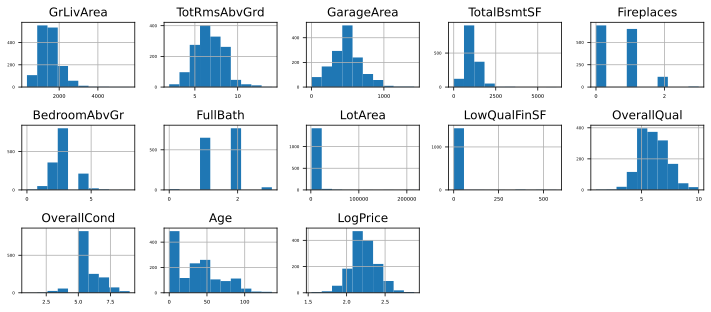

In [9]:
# show the feature distributions
foo = df.hist(layout=(14,5), figsize=(10,20), xlabelsize=5, ylabelsize=4)
plt.tight_layout()
plt.show()

And here are some simple statistics of the features.

In [10]:
df.describe()

,GrLivArea,TotRmsAbvGrd,GarageArea,TotalBsmtSF,Fireplaces,BedroomAbvGr,FullBath,LotArea,LowQualFinSF,OverallQual,OverallCond,Age,LogPrice
count,1460.00000,1460.00000,1460.00000,1460.00000,1460.00000,1460.00000,1460.00000,1460.00000,1460.00000,1460.00000,1460.00000,1460.00000,1460.00000
mean,1515.46370,6.51781,472.98014,1057.42945,0.61301,2.86644,1.56507,10516.82808,5.84452,6.09932,5.57534,36.54795,2.22198
std,525.48038,1.62539,213.80484,438.70532,0.64467,0.81578,0.55092,9981.26493,48.62308,1.38300,1.11280,30.25015,0.17348
min,334.00000,2.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1300.00000,0.00000,1.00000,1.00000,0.00000,1.54283
25%,1129.50000,5.00000,334.50000,795.75000,0.00000,2.00000,1.00000,7553.50000,0.00000,5.00000,5.00000,8.00000,2.11386
50%,1464.00000,6.00000,480.00000,991.50000,1.00000,3.00000,2.00000,9478.50000,0.00000,6.00000,5.00000,35.00000,2.21219
75%,1776.75000,7.00000,576.00000,1298.25000,1.00000,3.00000,2.00000,11601.50000,0.00000,7.00000,6.00000,54.00000,2.33041
max,5642.00000,14.00000,1418.00000,6110.00000,3.00000,8.00000,3.00000,215245.00000,572.00000,10.00000,9.00000,136.00000,2.87795


# Task 1: Regression
In the first task, we will predict the housing price from the other features using Linear Regression, and then interpret which features are most informative of the price. 

The below cell will extract the features and target, and create the training/test sets.

In [11]:
from sklearn.model_selection import train_test_split

# extract the data
X = df.drop(columns=['LogPrice'])
y = df['LogPrice']

# Ensure all columns are numeric
X = X.apply(pd.to_numeric)
y = pd.to_numeric(y)

# add constant term to linear model
X = sm.add_constant(X)

# split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5495)

## Data Pre-processing
Now perform pre-processing of data to improve interpretability of the model. Do some features need to be z-scored? Should some features be transformed?

In [ ]:
### INSERT YOUR CODE HERE

## Model Fitting

Fit the linear regression model.  Also check the predicition error on the test set to make sure your model is valid. 

In [ ]:
### INSERT YOUR CODE HERE

## Model Interpretation
Interpret the model using weight plots, effects plots, etc. 
Examine a few predictions and interpret how those predictions were made.

In [ ]:
### INSERT YOUR CODE HERE

## Summary of Interpretation

Provide a summary of your interpretation. Which features were important?  And what was their effect on the prediction?
- **INSERT YOUR ANSWER HERE**
- ...
- ...

# Task 2: Classification

In the 2nd task, we will analyze a model that predicts whether the house has a fireplace or not. 

First we define the data.

In [ ]:
# extract the data
X = df.drop(columns=['Fireplaces'])
y = df['Fireplaces'] > 0

# Ensure all columns are numeric
X = X.apply(pd.to_numeric)
y = pd.to_numeric(y)

# add constant term to linear model
X = sm.add_constant(X)

# split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5495)

In [ ]:
X_train

## Data Pre-processing
Put your pre-processing code here.

In [ ]:
### INSERT YOUR CODE HERE

## Model Fitting
Run the model fitting code for logistic regression (using `Logit` in `statsmodels`). Evaluate on the test set to confirm your classifier is valid.

In [ ]:
### INSERT YOUR CODE HERE

## Model Interpretation

Interpret model using the techniques learned in class.

In [ ]:
### INSERT YOUR CODE HERE

## Summary of Interpretation

Provide a summary of your interpretation. Which features were important?  And what was their effect on the prediction?
- **INSERT YOUR ANSWER HERE**
- ...
- ...